In [1]:
from pathlib import Path
from cycler import cycler
import sys
from joblib import dump

sys.path.append('..')
from utils import (
    draw_pr_curve_from_cv_results,
    print_cv_results,
    cv_results_to_long
    )

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from aeon.classification.shapelet_based import ShapeletTransformClassifier
from aeon.transformations.collection import Normalizer
from sklearn.model_selection import cross_validate, GridSearchCV, StratifiedKFold
from aeon.visualisation import ShapeletClassifierVisualizer

In [4]:
sns.set_theme(context='notebook', style='whitegrid', palette='muted', rc={'figure.figsize': (12, 4)})

In [5]:
data_dir = Path('../../results')

train = pd.read_csv(data_dir / 'train_ts.csv', index_col='id').reset_index(drop=True)
train['action'] = train['genre'].map(lambda x: 'Action' in x)

train_X = train[[str(i) for i in range(100)]].values.reshape(len(train), 1, 100)
train_X = Normalizer().fit_transform(train_X)
train_y = train['action']

In [6]:
grid_cv = StratifiedKFold(5)
cv = StratifiedKFold(shuffle=True, random_state=42)

It is not necessary for shapelet extraction for the timeseries to be amplitude scaled, but we do in order to have interpretable visualizations.

In [7]:
rf = RandomForestClassifier(min_samples_leaf=3, random_state=42)
dt = DecisionTreeClassifier(random_state=42)

In [8]:
stc = ShapeletTransformClassifier(
    n_shapelet_samples=1000,
    max_shapelets=10,
    n_jobs=-1,
    random_state=42
)

In [9]:
grid = GridSearchCV(stc,
                    dict(max_shapelet_length=(14, 28, 50, 100),
                    estimator=(dt, rf)),
                    cv=grid_cv,
                    verbose=2,
                    scoring='average_precision',
                    n_jobs=-1)

In [10]:
%%time
grid.fit(train_X, train_y)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END estimator=DecisionTreeClassifier(random_state=42), max_shapelet_length=14; total time=  42.6s
[CV] END estimator=DecisionTreeClassifier(random_state=42), max_shapelet_length=28; total time=  42.4s
[CV] END estimator=DecisionTreeClassifier(random_state=42), max_shapelet_length=28; total time=  42.7s
[CV] END estimator=DecisionTreeClassifier(random_state=42), max_shapelet_length=14; total time=  43.2s
[CV] END estimator=DecisionTreeClassifier(random_state=42), max_shapelet_length=14; total time=  42.8s
[CV] END estimator=DecisionTreeClassifier(random_state=42), max_shapelet_length=14; total time=  43.1s
[CV] END estimator=DecisionTreeClassifier(random_state=42), max_shapelet_length=28; total time=  43.2s
[CV] END estimator=DecisionTreeClassifier(random_state=42), max_shapelet_length=14; total time=  43.5s
[CV] END estimator=DecisionTreeClassifier(random_state=42), max_shapelet_length=28; total time=  32.4s
[CV] END esti

,estimator,ShapeletTrans...ndom_state=42)
,param_grid,"{'estimator': (DecisionTreeC...ndom_state=42), ...), 'max_shapelet_length': (14, ...)}"
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


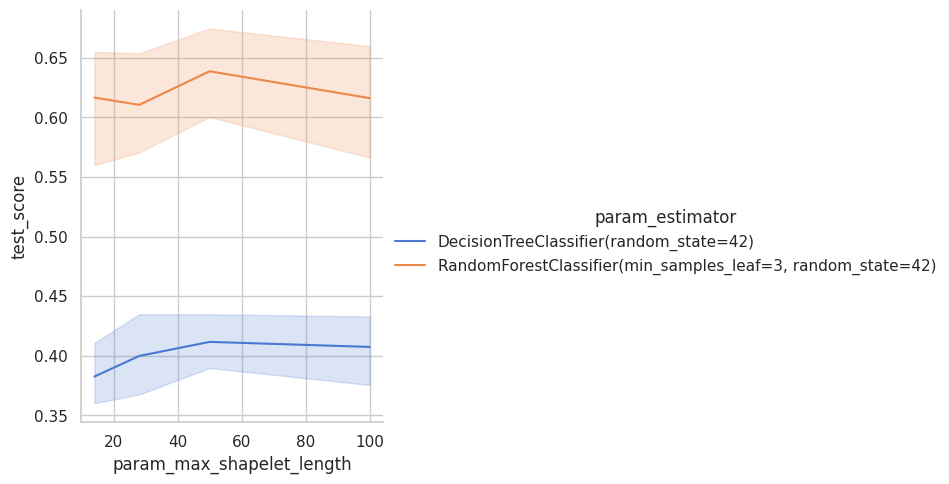

In [12]:
results = cv_results_to_long(grid.cv_results_)
sns.relplot(results, x='param_max_shapelet_length', y='test_score', hue='param_estimator', kind='line')

In [13]:
grid.best_params_

{'estimator': RandomForestClassifier(min_samples_leaf=3, random_state=42),
 'max_shapelet_length': 50}

In [14]:
grid.best_score_

np.float64(0.6386762665354901)

In [15]:
cv_results = cross_validate(grid.best_estimator_, train_X, train_y,
                            scoring=('precision', 'recall', 'f1', 'average_precision'), cv=cv,
                            n_jobs=-1, return_train_score=True, return_estimator=True,
                            return_indices=True)
print_cv_results(cv_results)

precision: 0.62 (0.03)
recall: 0.43 (0.05)
f1: 0.51 (0.04)
average_precision: 0.59 (0.1)


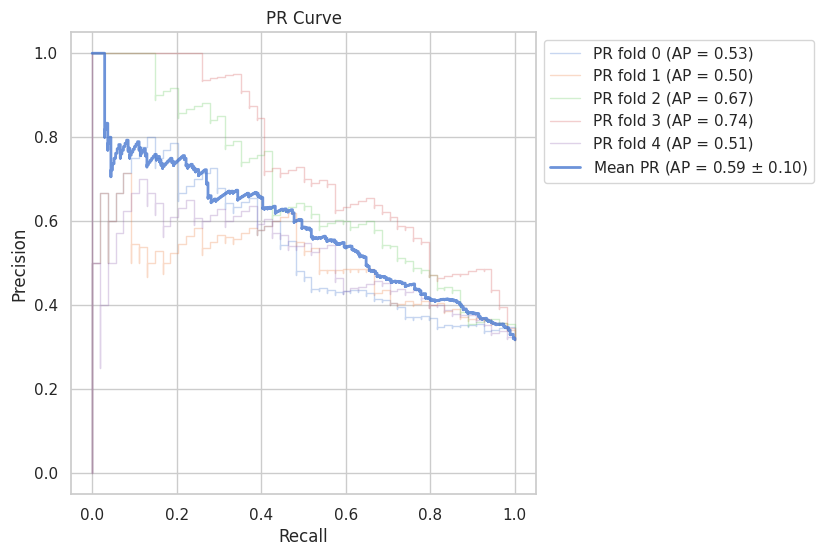

In [16]:
draw_pr_curve_from_cv_results(cv_results, train_X, train_y)

## Tune decision treshold

In [17]:
from sklearn.model_selection import TunedThresholdClassifierCV

In [18]:
tuned_model = TunedThresholdClassifierCV(grid.best_estimator_, scoring='f1', store_cv_results=True)
tuned_model.fit(train_X, train_y)
print(f'{tuned_model.best_threshold_=:.2f}')

tuned_model.best_threshold_=0.32


In [19]:
print(tuned_model.best_score_)

0.6149215003315758


## Shapelets analysis

In [20]:
clf = grid.best_estimator_
clf

,n_shapelet_samples,1000
,max_shapelets,10
,max_shapelet_length,50
,estimator,RandomForestC...ndom_state=42)
,transform_limit_in_minutes,0
,time_limit_in_minutes,0
,contract_max_n_shapelet_samples,inf
,n_jobs,-1
,batch_size,100
,random_state,42
,n_estimators,100


In [21]:
sc_viz = ShapeletClassifierVisualizer(clf)

[<Figure size 1800x1200 with 4 Axes>,
 <Figure size 1800x1200 with 4 Axes>,
 <Figure size 1800x1200 with 4 Axes>,
 <Figure size 1800x1200 with 4 Axes>,
 <Figure size 1800x1200 with 4 Axes>,
 <Figure size 1800x1200 with 4 Axes>,
 <Figure size 1800x1200 with 4 Axes>,
 <Figure size 1800x1200 with 4 Axes>,
 <Figure size 1800x1200 with 4 Axes>,
 <Figure size 1800x1200 with 4 Axes>]

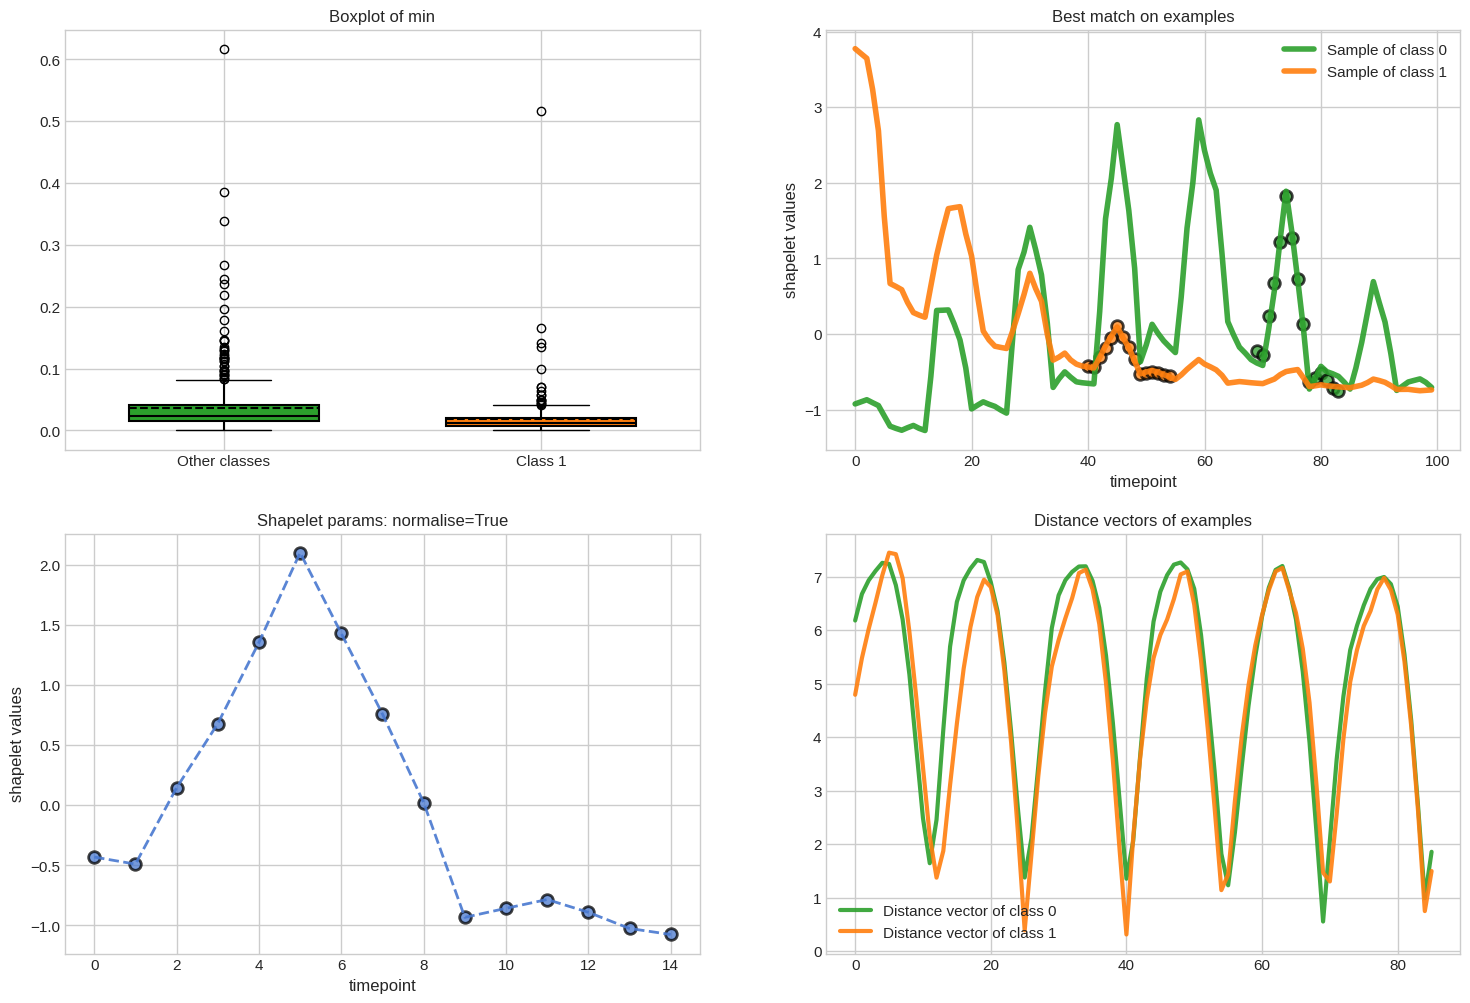

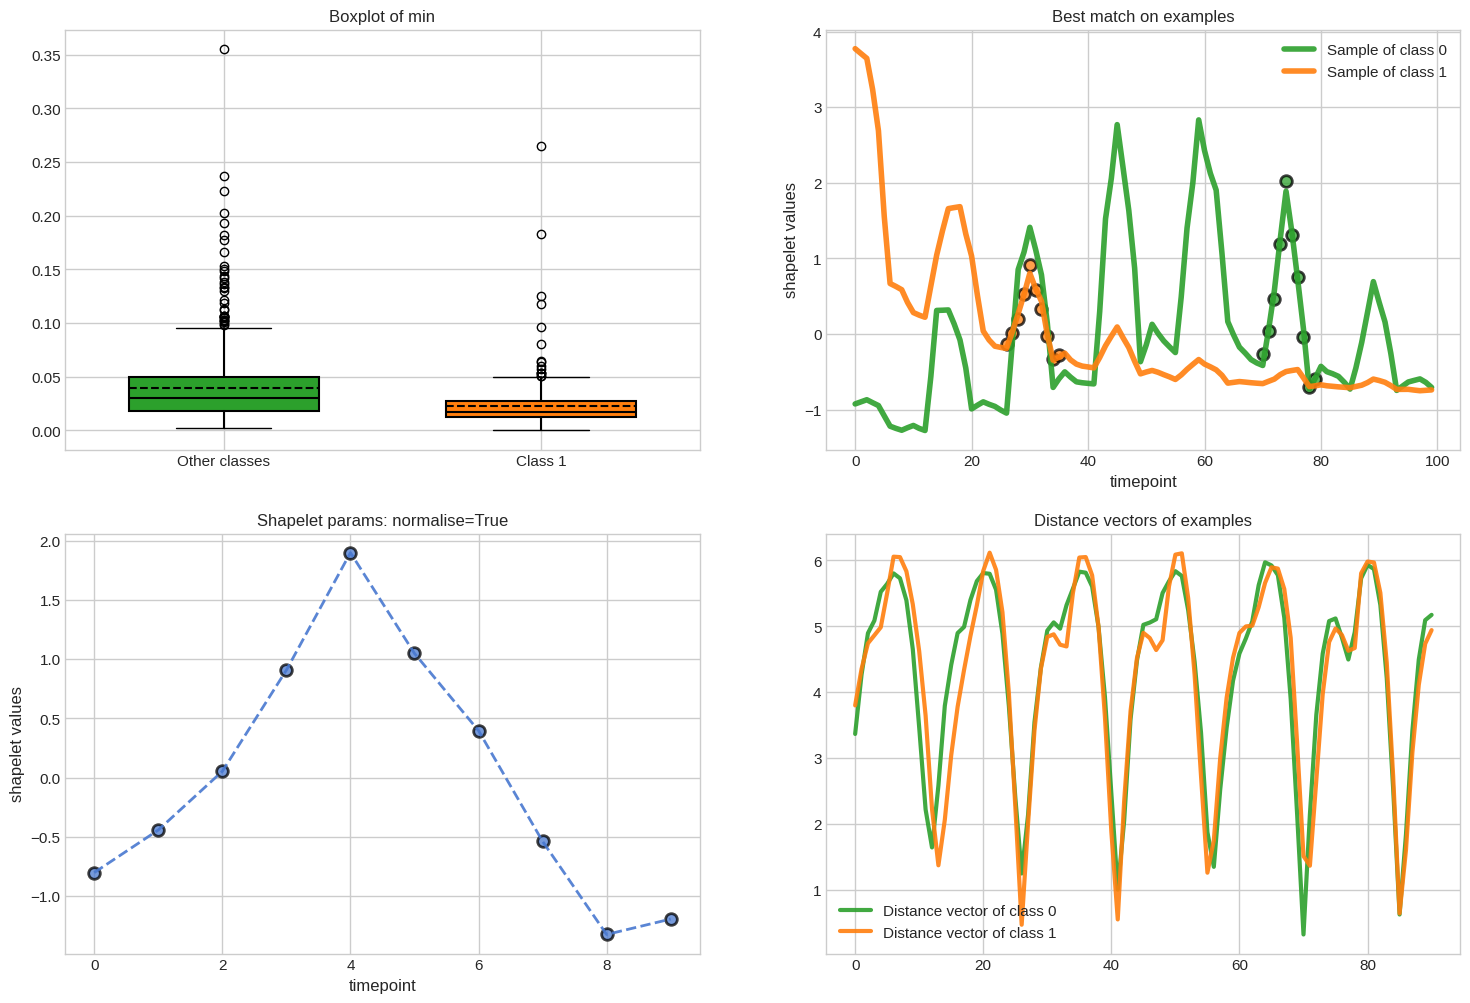

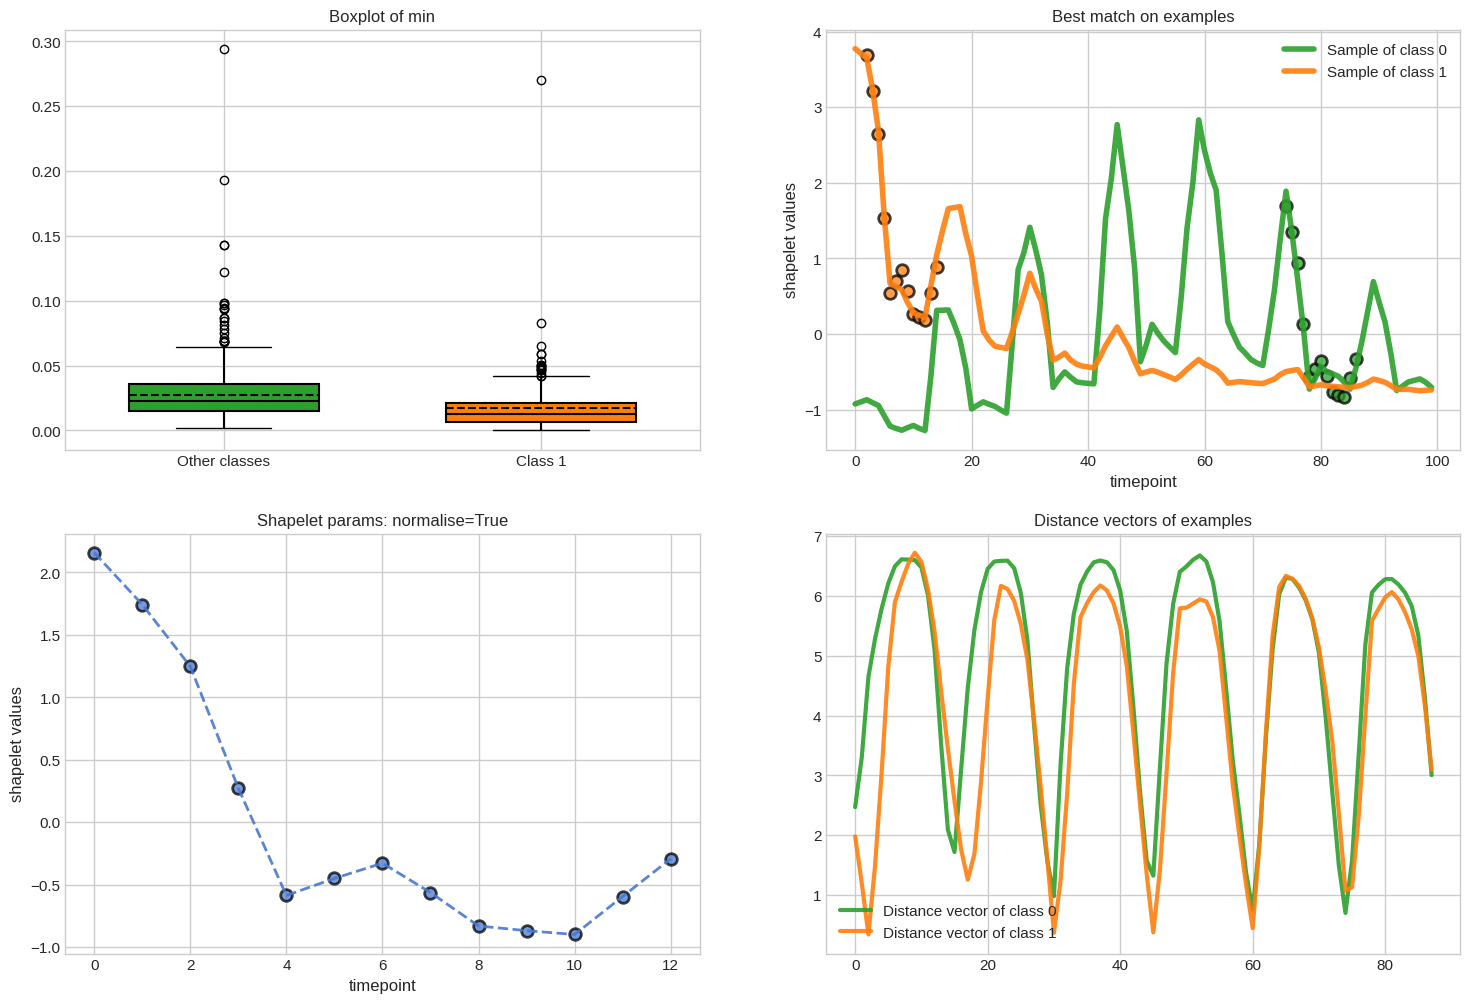

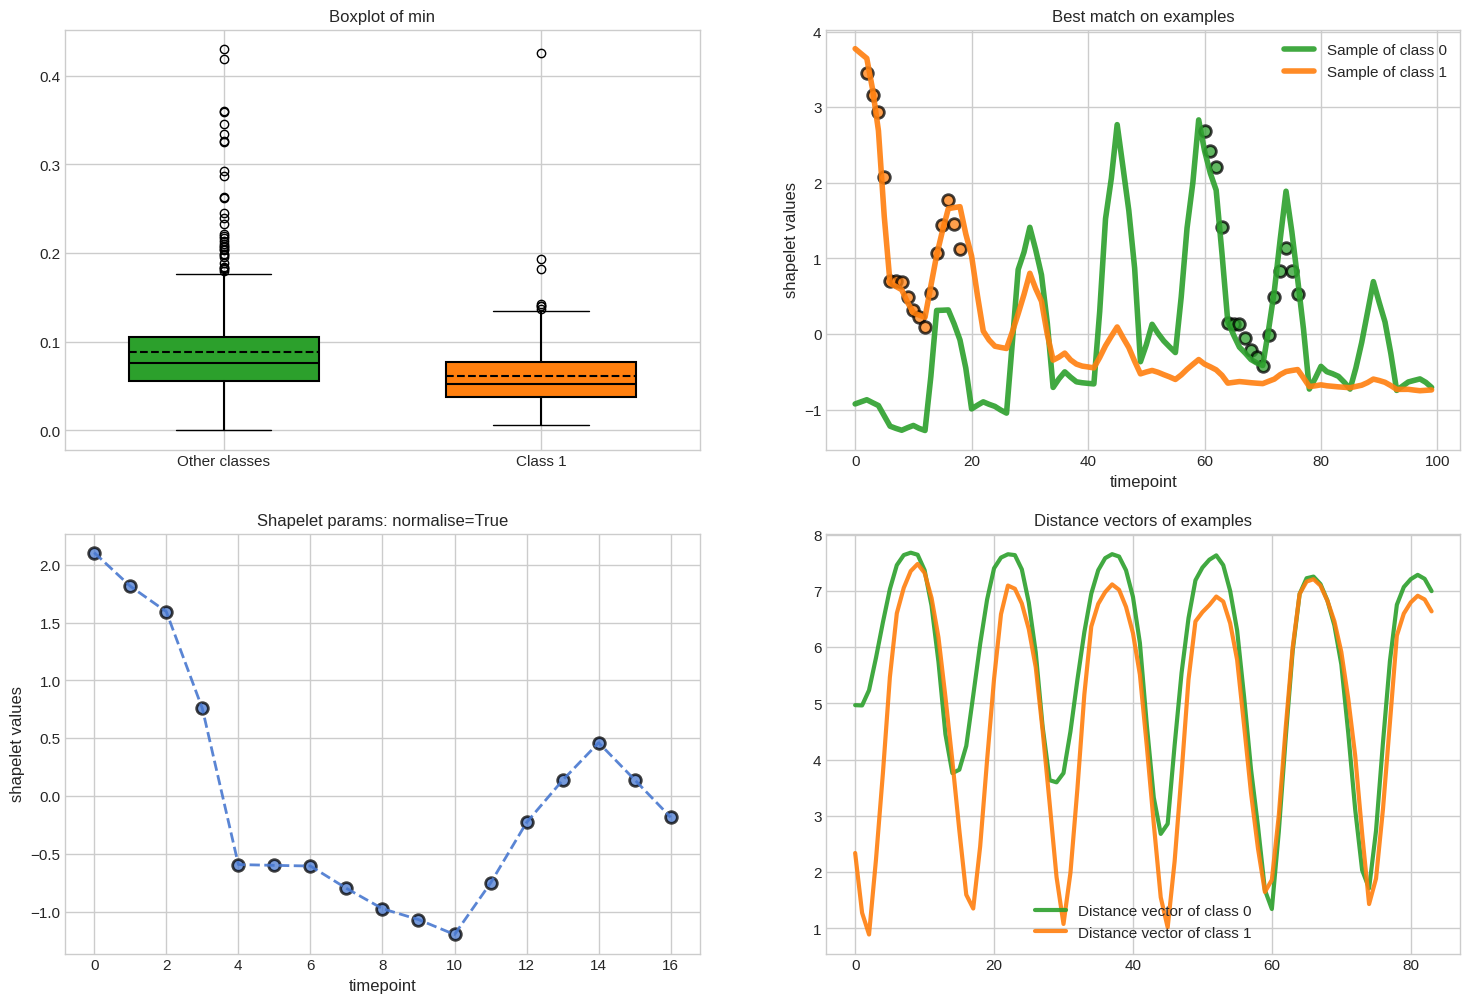

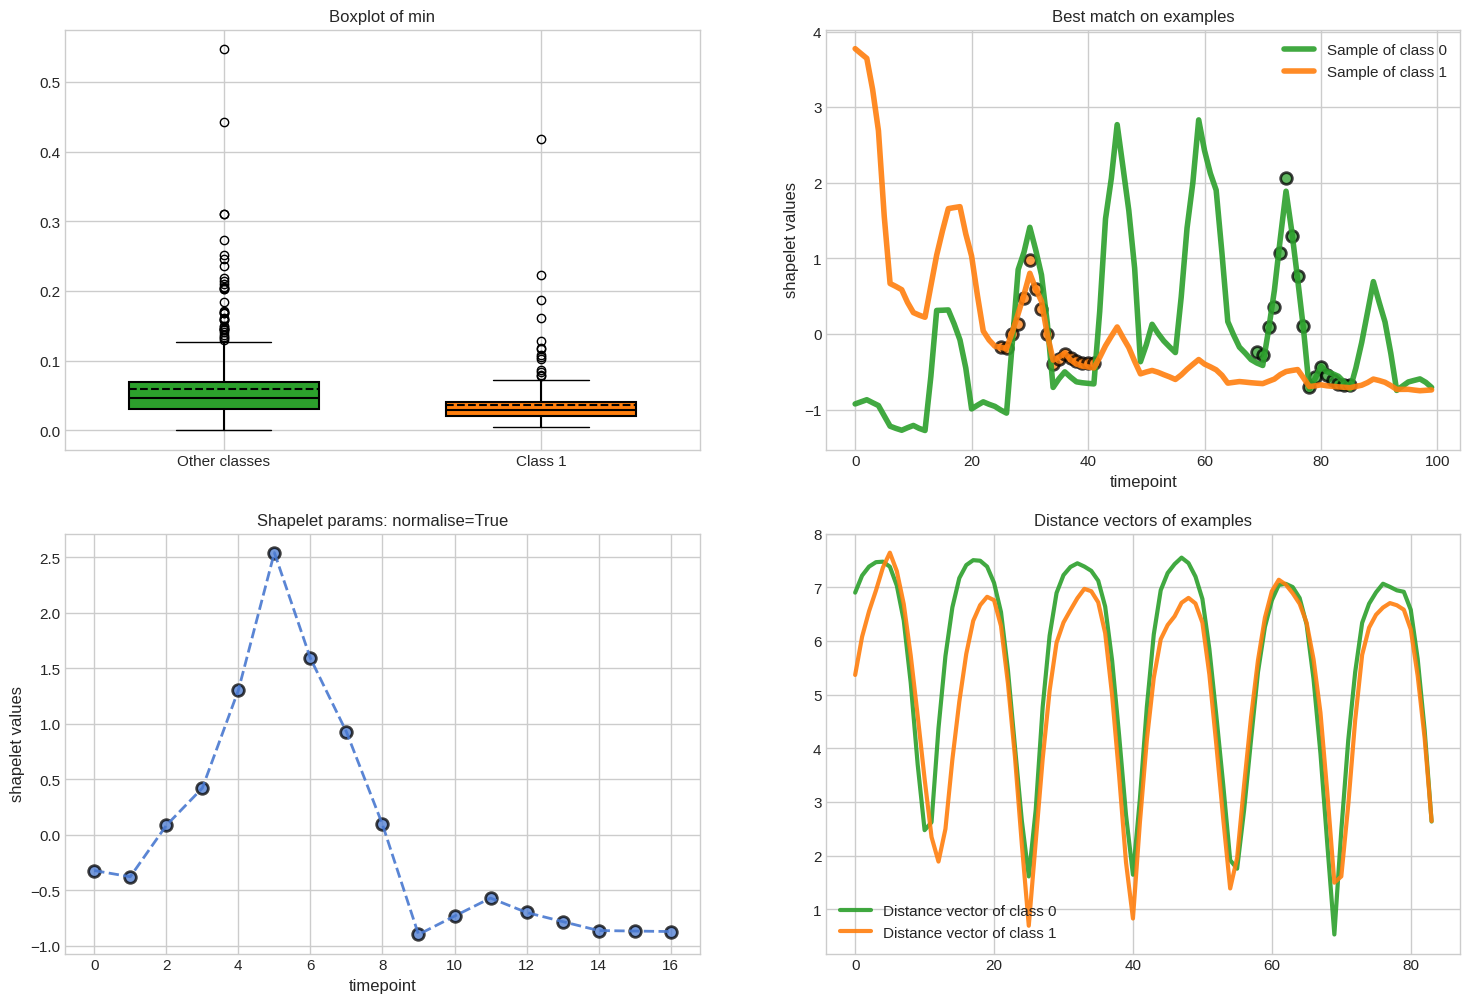

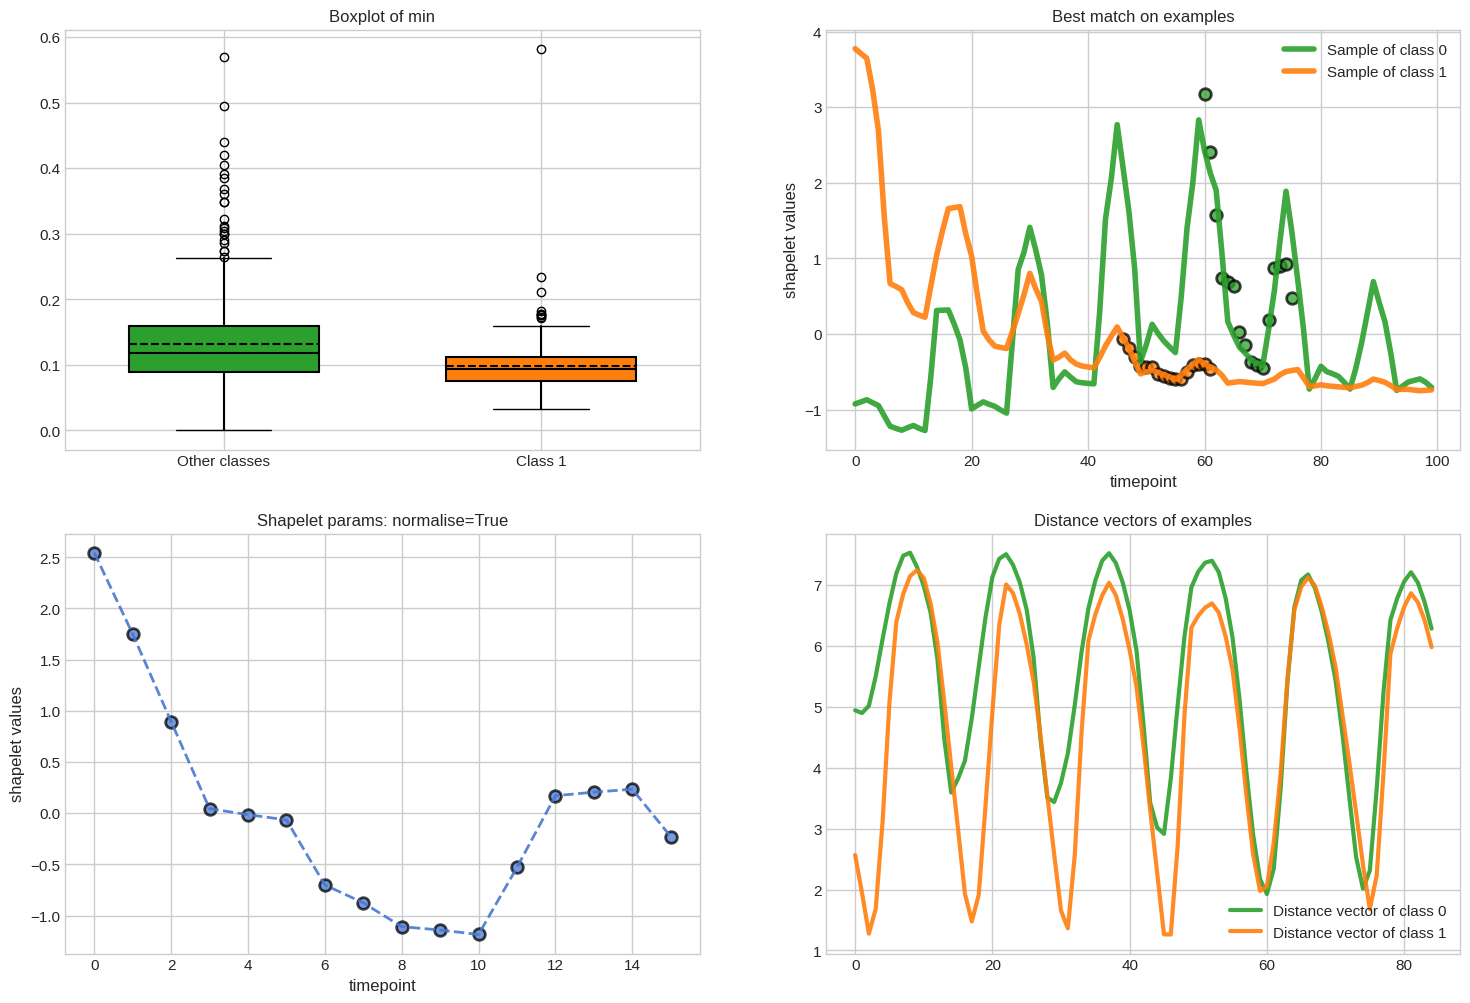

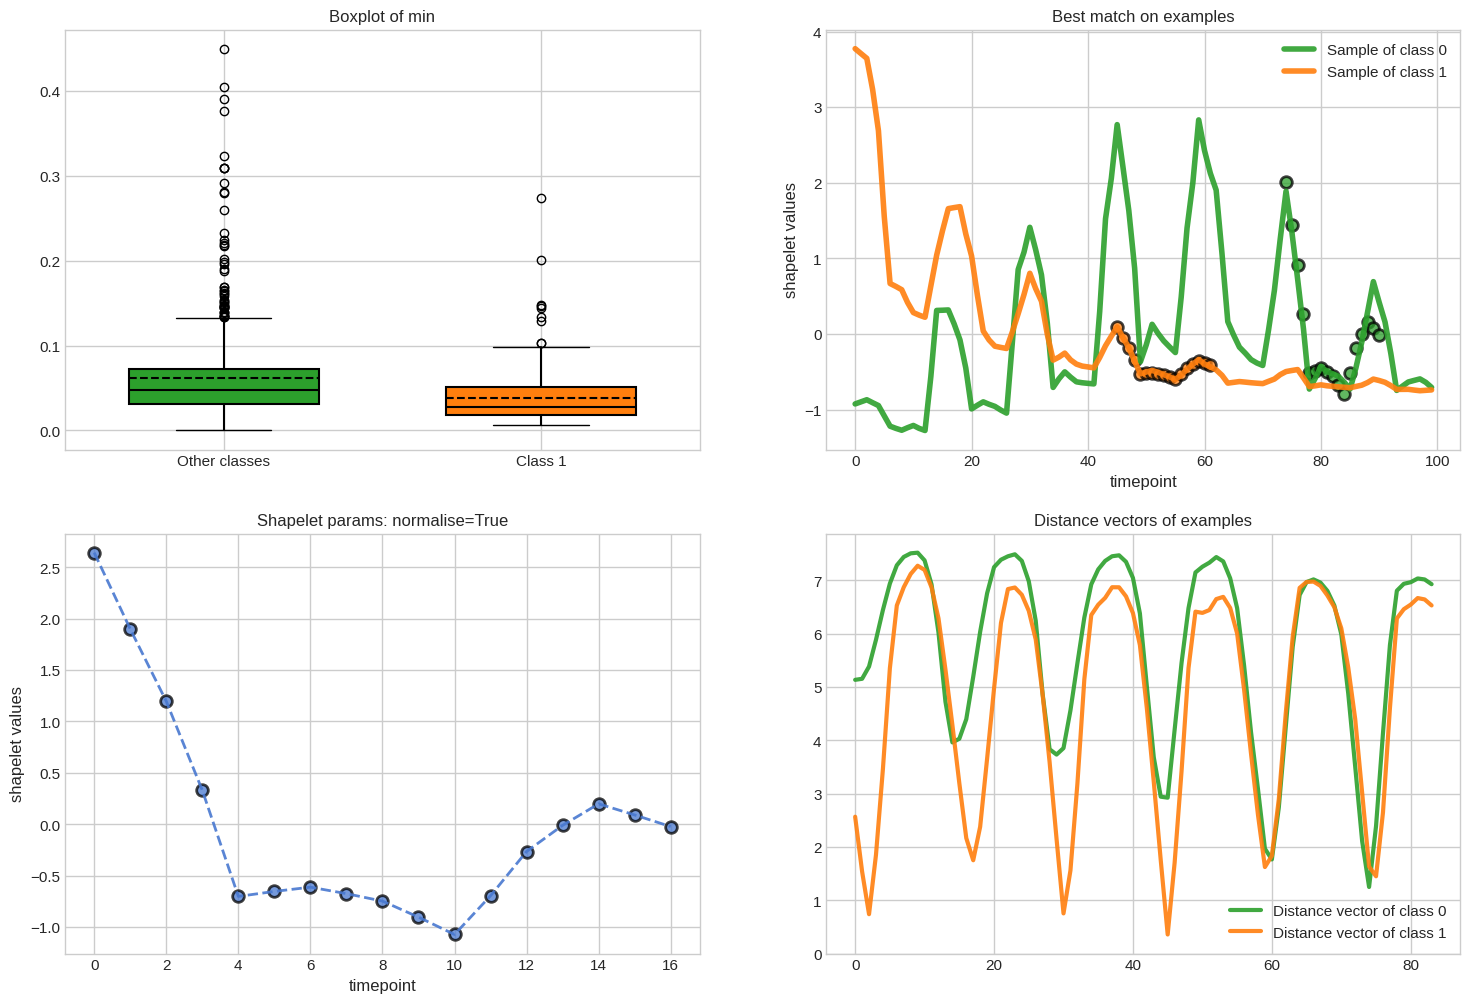

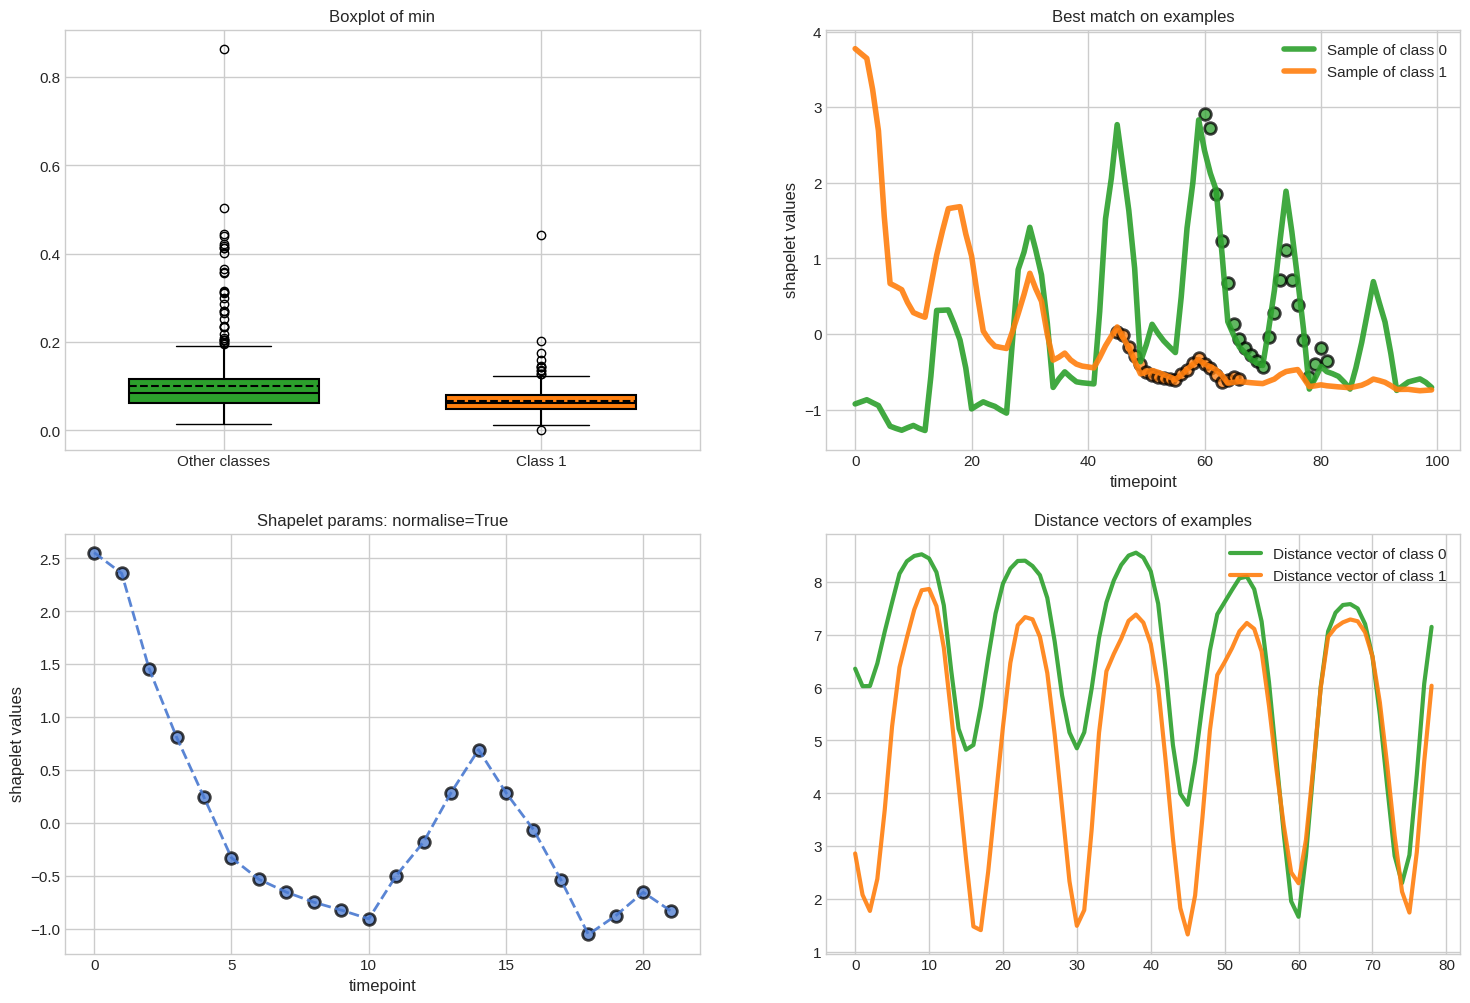

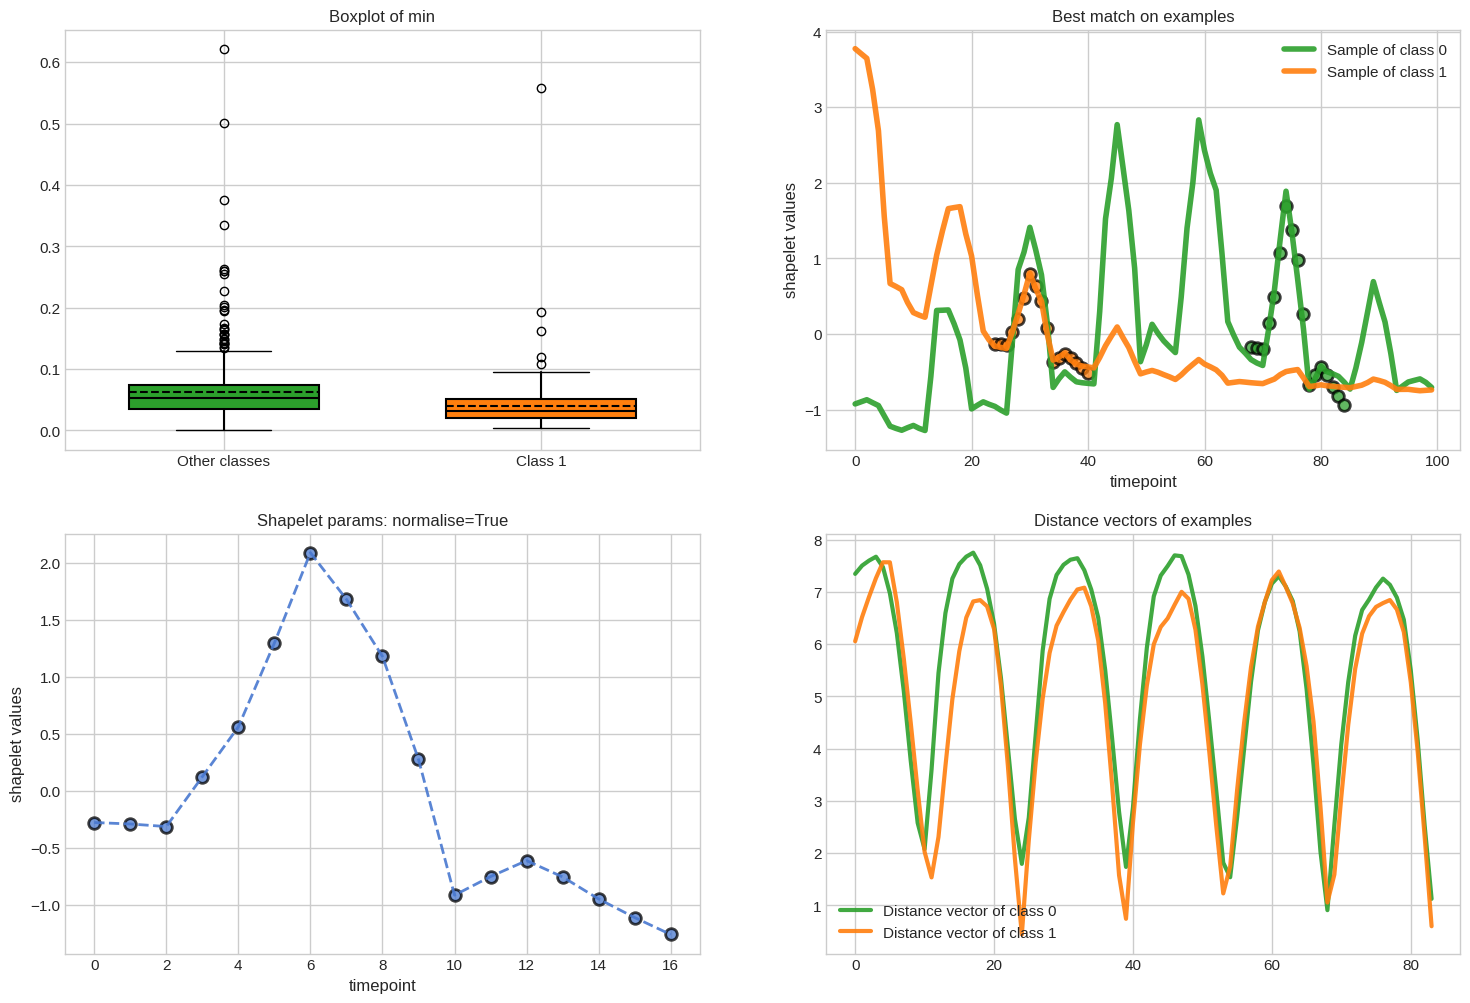

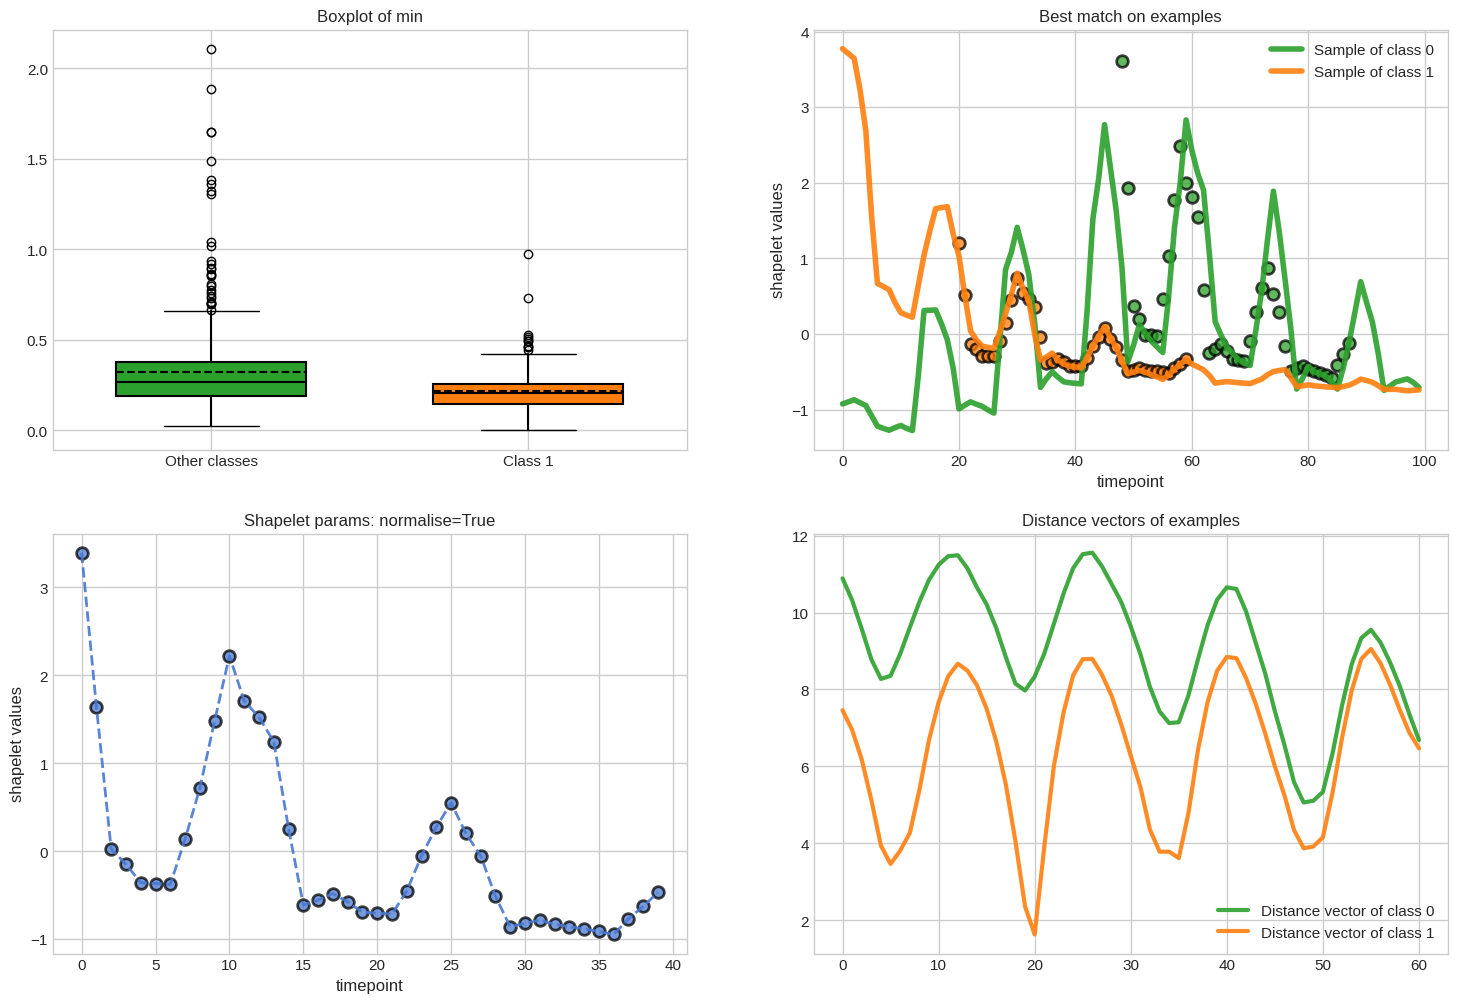

In [22]:
palette = sns.color_palette('muted')
sc_viz.visualize_shapelets_one_class(train_X, train_y, class_id=1,
                                     n_shp=10,
                                     id_example_other=469,
                                     id_example_class=192,
                                     matplotlib_style='seaborn-v0_8-whitegrid',
                                     figure_options={"figsize": (18, 12), "nrows": 2, "ncols": 2},
                                     rc_Params_options={"axes.prop_cycle": cycler(color=palette)}
                                     )

Makes probably sense to keep the last one.
This is a shapelet for the positive class.

In [23]:
shapelets = clf._transformer.shapelets

Each item in the list is a tuple containing the following 7 items:
1. shapelet information gain
2. shapelet length
3. start position the shapelet was extracted from
4. shapelet dimension
5. index of the instance the shapelet was extracted from in fit
6. class value of the shapelet
7. The z-normalised shapelet array


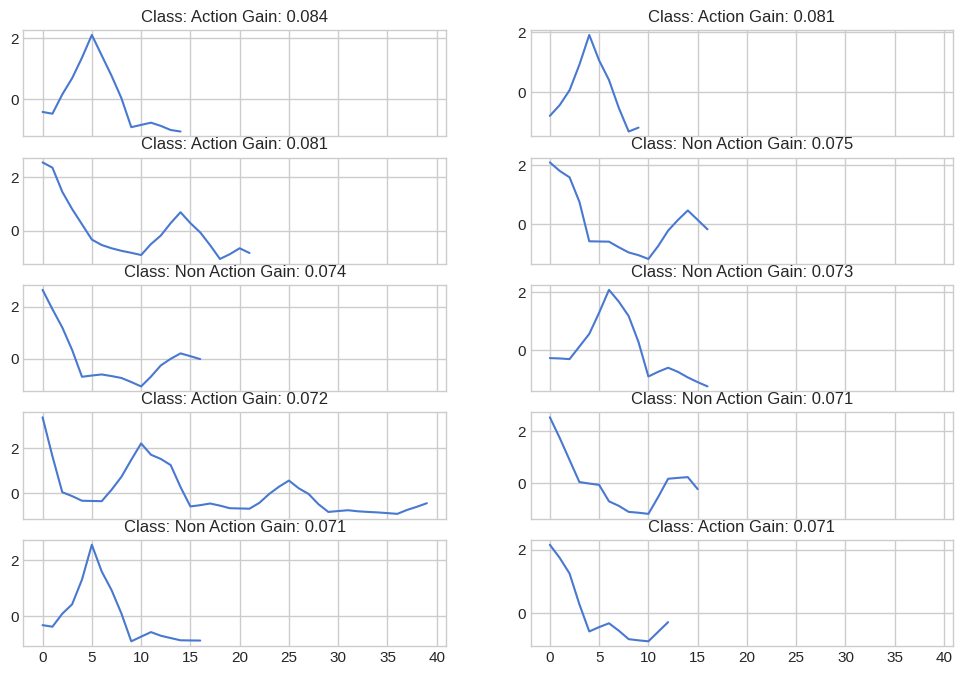

In [24]:
fig, axs = plt.subplots(5, 2, sharex=True, sharey=False, figsize=(12, 8))

for i, (gain, length, start, _, ts_index, class_value, shapelet) in enumerate(shapelets):
    row, col = divmod(i, 2)
    shap_class = 'Action' if class_value else 'Non Action'
    axs[row][col].plot(shapelet)
    axs[row][col].set_title(f'Class: {shap_class} Gain: {round(gain, 3)}')

Almost all retrieve shapelets have a length of around two weeks, which corroborates our observations on the seasonality of the time series we analyzed.

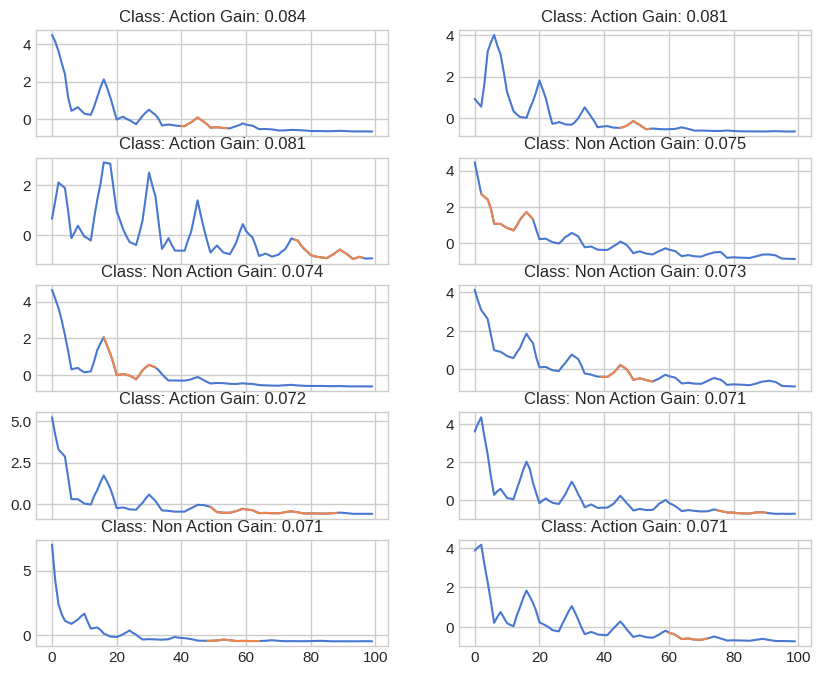

In [25]:
fig, axs = plt.subplots(5, 2, sharex=True, sharey=False, figsize=(10, 8))

for i, (gain, length, start, _, ts_index, class_value, shapelet) in enumerate(shapelets):
    row, col = divmod(i, 2)
    shap_class = 'Action' if class_value else 'Non Action'
    ts = train_X[ts_index][0]
    axs[row][col].plot(ts)
    axs[row][col].plot(np.arange(start, start + length), ts[start:start+length])
    axs[row][col].set_title(f'Class: {shap_class} Gain: {round(gain, 3)}')

## Test

In [26]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, PrecisionRecallDisplay

In [27]:
test = pd.read_csv(data_dir / 'test_ts.csv', index_col='id').reset_index(drop=True)
test['action'] = test['genre'].map(lambda x: 'Action' in x)

test_X = test[[str(i) for i in range(100)]].values.reshape(len(test), 1, 100)
test_X = Normalizer().fit_transform(test_X)
test_y = test['action']

In [28]:
y_pred = tuned_model.predict(test_X)
print(classification_report(test_y, y_pred))

              precision    recall  f1-score   support

       False       0.83      0.78      0.81       195
        True       0.58      0.65      0.61        89

    accuracy                           0.74       284
   macro avg       0.71      0.72      0.71       284
weighted avg       0.75      0.74      0.75       284



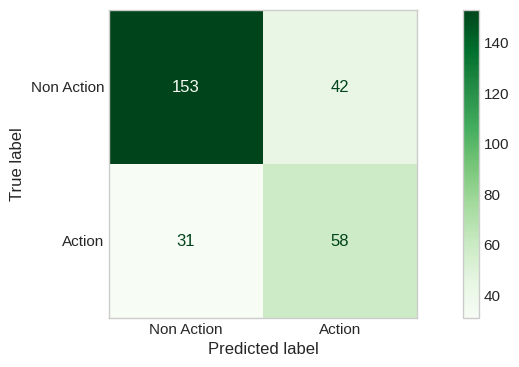

In [29]:
ConfusionMatrixDisplay.from_predictions(test_y, y_pred, cmap='Greens', display_labels=('Non Action', 'Action'))
plt.grid(False)

In [30]:
y_score = tuned_model.predict_proba(test_X)

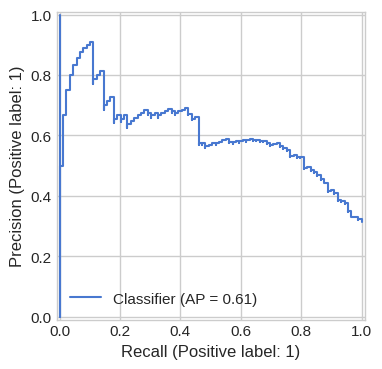

In [31]:
PrecisionRecallDisplay.from_predictions(test_y, y_score[:,1])

Looks like there are some one high ranking false positives.

In [32]:
y_score[:,1].argsort()[-2:]

array([87, 47])

In [33]:
test.iloc[47,:]

title              Annihilation
startYear                  2018
runtimeMinutes              115
numVotes                 383786
countryOfOrigin           US,GB
                       ...     
96                      22459.0
97                      21174.0
98                      19160.0
99                      16716.0
action                    False
Name: 47, Length: 114, dtype: object

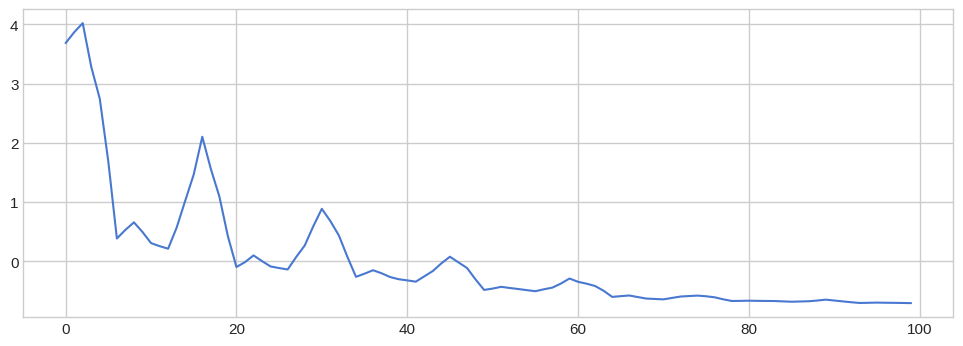

In [34]:
plt.plot(test_X[47][0])

Persist model for general assesment.

In [35]:
models_dir = Path('../../results/models')
with open(models_dir / 'rst.pkl', 'wb') as outfile:
    dump(tuned_model, outfile, protocol=5)